In [1]:
from datasets import load_dataset
import json

ds = load_dataset("pagarsky/agent-trace")["train"]

row = ds[0]

print(row.keys())

print(json.loads(row["llm_steps_json"]))

dict_keys(['trace_id', 'timestamp_utc', 'prompt', 'model', 'dataset_name', 'task_id', 'run_id', 'total_duration_ms', 'tool_span_count', 'llm_step_count', 'spans_json', 'llm_steps_json', 'metadata_json', 'raw_file'])
[{'step_id': '58259a84-7140-42c3-a53c-f04d37d437d9', 'step_number': 1, 'model_output': 'Action:', 'reasoning_content': 'Okay, I need to write a Python function to remove the first and last occurrence of a given character from a string. Let\'s see. The test cases provided are:\n\nFirst test case: "hello","l" should become "heo". Let\'s check. The original string is h-e-l-l-o. Removing the first \'l\' and the last \'l\' (assuming that the last occurrence is the second \'l\' in the middle). Wait, no. Wait, in "hello", the first occurrence of \'l\' is at index 2 (third character), and the last occurrence is at index 5 (the sixth character). So removing both would leave \'heo\'. So that test case is correct.\n\nSecond test case: "abcda","a". The original string is a-b-c-d-a. The

In [3]:
# loading dataset

from datasets import load_dataset
import json
from pprint import pprint

dataset = load_dataset("pagarsky/agent-trace")


In [7]:
# printing samples

print(dataset.keys())
print(dataset["train"].features)

dict_keys(['train'])
{'trace_id': Value('string'), 'timestamp_utc': Value('string'), 'prompt': Value('string'), 'model': Value('string'), 'dataset_name': Value('string'), 'task_id': Value('int64'), 'run_id': Value('string'), 'total_duration_ms': Value('float64'), 'tool_span_count': Value('int64'), 'llm_step_count': Value('int64'), 'spans_json': Value('string'), 'llm_steps_json': Value('string'), 'metadata_json': Value('string'), 'raw_file': Value('string')}


In [8]:
import json

sample = dataset["train"][0]
print(json.dumps(sample, indent=2, ensure_ascii=False))

{
  "trace_id": "dc797f46-d2f2-453c-b5d3-3d8e761b395b",
  "timestamp_utc": "2026-03-28T13:32:06.997116+00:00",
  "prompt": "Write a python function to remove first and last occurrence of a given character from the string.\n\nTest cases:\nassert remove_Occ(\"hello\",\"l\") == \"heo\"\nassert remove_Occ(\"abcda\",\"a\") == \"bcd\"\nassert remove_Occ(\"PHP\",\"P\") == \"H\"",
  "model": "Qwen/Qwen3-0.6B",
  "dataset_name": "mbpp",
  "task_id": 11,
  "run_id": "collect-0_6B-20260328T133144Z-mbpp",
  "total_duration_ms": 18909.24975,
  "tool_span_count": 1,
  "llm_step_count": 1,
  "spans_json": "[{\"span_id\": \"a5299278-d41e-4ee1-a6ca-6d3265d35e25\", \"type\": \"TOOL\", \"tool_name\": \"final_answer\", \"tool_input\": \"kwargs={'answer': \\\"def remove_occurrence(s, char):\\\\n    s = list(s)\\\\n    i = s.index(char)\\\\n    del s[i]\\\\n    return ''.join(s)\\\"}\", \"tool_output\": \"def remove_occurrence(s, char):\\n    s = list(s)\\n    i = s.index(char)\\n    del s[i]\\n    return '

In [19]:
print(type(dataset['train']))
print(type(dataset['train'][0]))
#print(dataset['train'][0])
print(json.dumps(dataset['train'][0], indent=2, ensure_ascii=False))

<class 'datasets.arrow_dataset.Dataset'>
<class 'dict'>
{
  "trace_id": "dc797f46-d2f2-453c-b5d3-3d8e761b395b",
  "timestamp_utc": "2026-03-28T13:32:06.997116+00:00",
  "prompt": "Write a python function to remove first and last occurrence of a given character from the string.\n\nTest cases:\nassert remove_Occ(\"hello\",\"l\") == \"heo\"\nassert remove_Occ(\"abcda\",\"a\") == \"bcd\"\nassert remove_Occ(\"PHP\",\"P\") == \"H\"",
  "model": "Qwen/Qwen3-0.6B",
  "dataset_name": "mbpp",
  "task_id": 11,
  "run_id": "collect-0_6B-20260328T133144Z-mbpp",
  "total_duration_ms": 18909.24975,
  "tool_span_count": 1,
  "llm_step_count": 1,
  "spans_json": "[{\"span_id\": \"a5299278-d41e-4ee1-a6ca-6d3265d35e25\", \"type\": \"TOOL\", \"tool_name\": \"final_answer\", \"tool_input\": \"kwargs={'answer': \\\"def remove_occurrence(s, char):\\\\n    s = list(s)\\\\n    i = s.index(char)\\\\n    del s[i]\\\\n    return ''.join(s)\\\"}\", \"tool_output\": \"def remove_occurrence(s, char):\\n    s = list(

In [ ]:
row = dataset["train"][0]

spans = json.loads(row["spans_json"])

print(type(spans))
print(type(spans[0]))
#print(spans[0])
print(json.dumps(spans[0], indent=2, ensure_ascii=False))

<class 'list'>
<class 'dict'>
{
  "span_id": "a5299278-d41e-4ee1-a6ca-6d3265d35e25",
  "type": "TOOL",
  "tool_name": "final_answer",
  "tool_input": "kwargs={'answer': \"def remove_occurrence(s, char):\\n    s = list(s)\\n    i = s.index(char)\\n    del s[i]\\n    return ''.join(s)\"}",
  "tool_output": "def remove_occurrence(s, char):\n    s = list(s)\n    i = s.index(char)\n    del s[i]\n    return ''.join(s)",
  "start_ns": 885980259162625,
  "end_ns": 885980259166833,
  "duration_ms": 0.004208,
  "telemetry": {
    "user_time_s": 5.999999999950489e-06,
    "system_time_s": 6.0000000000060005e-06,
    "max_rss_bytes": 168804352,
    "read_bytes": 0,
    "write_bytes": 0
  },
  "exit_code": 0,
  "parent_span_id": null
}


In [ ]:
def pretty_spans(row):
    spans = json.loads(row["spans_json"])

    for i, span in enumerate(spans):
        print(f"\nSPAN {i}")
        print(f"TYPE: {span.get('type')}")
        print(f"TOOL: {span.get('tool_name')}")
        print(f"INPUT: {span.get('tool_input')}")
        print(f"OUTPUT: {span.get('tool_output')}")

In [16]:
pretty_spans(dataset['train'][0])


SPAN 0
TYPE: TOOL
TOOL: final_answer
INPUT: kwargs={'answer': "def remove_occurrence(s, char):\n    s = list(s)\n    i = s.index(char)\n    del s[i]\n    return ''.join(s)"}
OUTPUT: def remove_occurrence(s, char):
    s = list(s)
    i = s.index(char)
    del s[i]
    return ''.join(s)


In [24]:
def pretty_steps(row):
    steps = json.loads(row["llm_steps_json"])

    for i, step in enumerate(steps):
        print(f"\nSTEP {i}")
        print(f"STEP NUMBER: {step.get('step_number')}")
        print(f"OUTPUT TOKENS: {step.get('output_tokens')}")
        print(f"INPUT TOKENS: {step.get('input_tokens')}")

        reasoning = step.get("reasoning_content")
        if reasoning:
            print(f"\nREASONING:")
            print(reasoning[:1000])

        print("\nTOOL CALLS:")
        print(step.get("tool_calls"))

In [25]:
pretty_steps(dataset["train"][0])


STEP 0
STEP NUMBER: 1
OUTPUT TOKENS: 1544
INPUT TOKENS: 1490

REASONING:
Okay, I need to write a Python function to remove the first and last occurrence of a given character from a string. Let's see. The test cases provided are:

First test case: "hello","l" should become "heo". Let's check. The original string is h-e-l-l-o. Removing the first 'l' and the last 'l' (assuming that the last occurrence is the second 'l' in the middle). Wait, no. Wait, in "hello", the first occurrence of 'l' is at index 2 (third character), and the last occurrence is at index 5 (the sixth character). So removing both would leave 'heo'. So that test case is correct.

Second test case: "abcda","a". The original string is a-b-c-d-a. The first occurrence is at index 0, and the last is at index 4. Removing both would leave "bcd".

Third test case: "PHP","P". The original string is P-H-P. The first occurrence is index 0, and the last is index 2. Removing both would leave "H".

So the function needs to remove the

In [27]:
# visualizing traces
def pretty_trace(row):
    print("=" * 80)
    print("PROMPT")
    print("=" * 80)
    print(row["prompt"])

    print("\n" + "=" * 80)
    print("LLM STEPS")
    print("=" * 80)

    for step in json.loads(row["llm_steps_json"]):
        print(f"\nSTEP {step['step_number']}")

        if step.get("reasoning_content"):
            print("\nREASONING:")
            print(step["reasoning_content"][:500])

        print("\nTOOL CALLS:")
        print(step.get("tool_calls"))

    print("\n" + "=" * 80)
    print("TOOL SPANS")
    print("=" * 80)

    for span in json.loads(row["spans_json"]):
        print(
            f"{span['tool_name']} "
            f"({span['duration_ms']:.2f} ms)"
        )

In [28]:
pretty_trace(dataset["train"][0])

PROMPT
Write a python function to remove first and last occurrence of a given character from the string.

Test cases:
assert remove_Occ("hello","l") == "heo"
assert remove_Occ("abcda","a") == "bcd"
assert remove_Occ("PHP","P") == "H"

LLM STEPS

STEP 1

REASONING:
Okay, I need to write a Python function to remove the first and last occurrence of a given character from a string. Let's see. The test cases provided are:

First test case: "hello","l" should become "heo". Let's check. The original string is h-e-l-l-o. Removing the first 'l' and the last 'l' (assuming that the last occurrence is the second 'l' in the middle). Wait, no. Wait, in "hello", the first occurrence of 'l' is at index 2 (third character), and the last occurrence is at index 5 (the sixth

TOOL CALLS:
[{'name': 'final_answer', 'arguments': {'answer': "def remove_occurrence(s, char):\n    s = list(s)\n    i = s.index(char)\n    del s[i]\n    return ''.join(s)"}}]

TOOL SPANS
final_answer (0.00 ms)


In [ ]:
# Basic dataset info
print("Dataset type:", type(dataset["train"]))
print("Number of rows:", len(dataset["train"]))

# First row
row = dataset["train"][0]

print("\nColumns:")
for col in row.keys():
    print(f"  - {col}")

print("\nColumn types:")
for k, v in row.items():
    print(f"{k}: {type(v).__name__}")

# Inspect spans_json
print("\n" + "="*80)
print("SPANS_JSON STRUCTURE")
print("="*80)

spans = json.loads(row["spans_json"])
print("Type:", type(spans).__name__)
print("Number of spans:", len(spans))

if spans:
    print("\nSpan keys:")
    pprint(list(spans[0].keys()))

    print("\nFirst span:")
    pprint(spans[0])

# Inspect llm_steps_json
print("\n" + "="*80)
print("LLM_STEPS_JSON STRUCTURE")
print("="*80)

steps = json.loads(row["llm_steps_json"])
print("Type:", type(steps).__name__)
print("Number of steps:", len(steps))

if steps:
    print("\nStep keys:")
    pprint(list(steps[0].keys()))

    print("\nFirst step:")
    pprint(steps[0])

# Inspect metadata_json
print("\n" + "="*80)
print("METADATA_JSON STRUCTURE")
print("="*80)

metadata = json.loads(row["metadata_json"])

print("Metadata keys:")
pprint(list(metadata.keys()))

print("\nMetadata:")
pprint(metadata)

Dataset type: <class 'datasets.arrow_dataset.Dataset'>
Number of rows: 1400

Columns:
  - trace_id
  - timestamp_utc
  - prompt
  - model
  - dataset_name
  - task_id
  - run_id
  - total_duration_ms
  - tool_span_count
  - llm_step_count
  - spans_json
  - llm_steps_json
  - metadata_json
  - raw_file

Column types:
trace_id: str
timestamp_utc: str
prompt: str
model: str
dataset_name: str
task_id: int
run_id: str
total_duration_ms: float
tool_span_count: int
llm_step_count: int
spans_json: str
llm_steps_json: str
metadata_json: str
raw_file: str

SPANS_JSON STRUCTURE
Type: list
Number of spans: 1

Span keys:
['span_id',
 'type',
 'tool_name',
 'tool_input',
 'tool_output',
 'start_ns',
 'end_ns',
 'duration_ms',
 'telemetry',
 'exit_code',
 'parent_span_id']

First span:
{'duration_ms': 0.004208,
 'end_ns': 885980259166833,
 'exit_code': 0,
 'parent_span_id': None,
 'span_id': 'a5299278-d41e-4ee1-a6ca-6d3265d35e25',
 'start_ns': 885980259162625,
 'telemetry': {'max_rss_bytes': 1688043

In [31]:
span_keys = set()
step_keys = set()

for row in dataset["train"]:
    for span in json.loads(row["spans_json"]):
        span_keys.update(span.keys())

    for step in json.loads(row["llm_steps_json"]):
        step_keys.update(step.keys())

print("SPAN KEYS")
print(sorted(span_keys))

print("\nSTEP KEYS")
print(sorted(step_keys))

SPAN KEYS
['duration_ms', 'end_ns', 'exit_code', 'parent_span_id', 'span_id', 'start_ns', 'telemetry', 'tool_input', 'tool_name', 'tool_output', 'type']

STEP KEYS
['duration_ms', 'input_tokens', 'model_output', 'output_tokens', 'reasoning_content', 'step_id', 'step_number', 'tool_calls']


In [ ]:
# checking structure

"""Analyze collected traces and print summary statistics."""

import argparse
import json
import sys
from collections import Counter
from pathlib import Path

def print_section(title: str):
    print(f"\n{'=' * 60}")
    print(f"  {title}")
    print(f"{'=' * 60}")


def percentile(values: list[float], p: int) -> float:
    if not values:
        return 0.0
    k = (len(values) - 1) * p / 100
    f = int(k)
    c = f + 1 if f + 1 < len(values) else f
    return values[f] + (k - f) * (values[c] - values[f])


def analyze(traces: list[dict]):
    # ── Overview ──
    print_section("Overview")
    n = len(traces)
    # flattens everything for counting 
    all_spans = [s for t in traces for s in t.get("spans", [])]
    all_steps = [s for t in traces for s in t.get("llm_steps", [])]
    print(f"  Traces:     {n}")
    print(f"  Tool spans: {len(all_spans)}")
    print(f"  LLM steps:  {len(all_steps)}")

    # compares two models 
    models = Counter(t.get("model") for t in traces)
    for model, count in models.most_common():
        print(f"  Model:      {model} ({count} traces)")

    # two benchmarks MBPP -> Python coding task 
    # NL2Bash -> shell command generation task 
    sources = Counter(t.get("metadata", {}).get("source", "unknown") for t in traces)
    for src, count in sources.most_common():
        print(f"  Source:     {src} ({count} traces)")

    # ── Trace duration ──
    # total runtime of an entire agent execution  
    print_section("Trace Duration")
    durations = sorted([t["total_duration_ms"] for t in traces if t.get("total_duration_ms")])
    if durations:
        print(f"  Min:    {durations[0]:>10.0f} ms")
        print(f"  P25:    {percentile(durations, 25):>10.0f} ms")
        print(f"  Median: {percentile(durations, 50):>10.0f} ms")
        print(f"  P75:    {percentile(durations, 75):>10.0f} ms")
        print(f"  P95:    {percentile(durations, 95):>10.0f} ms")
        print(f"  Max:    {durations[-1]:>10.0f} ms")
        print(f"  Total:  {sum(durations)/1000:>10.1f} s")

    # ── Steps per trace ──
    # measures agent complexity 
    print_section("Steps per Trace")
    steps_per = sorted([len(t.get("llm_steps", [])) for t in traces])
    spans_per = sorted([len(t.get("spans", [])) for t in traces])
    if steps_per:
        step_counts = Counter(steps_per)
        print(f"  LLM steps:  min={steps_per[0]}, median={percentile(steps_per, 50):.0f}, max={steps_per[-1]}")
        print(f"  Tool spans: min={spans_per[0]}, median={percentile(spans_per, 50):.0f}, max={spans_per[-1]}")
        print(f"  Distribution (LLM steps):")
        for count in sorted(step_counts):
            bar = "#" * step_counts[count]
            print(f"    {count:>2} steps: {step_counts[count]:>3} traces  {bar}")

    # ── Tool usage ──
    # counts tool invocations
    print_section("Tool Usage")
    tool_counts = Counter(s["tool_name"] for s in all_spans)
    tool_durations: dict[str, list[float]] = {}
    for s in all_spans:
        name = s["tool_name"]
        tool_durations.setdefault(name, []).append(s["duration_ms"])

    for tool, count in tool_counts.most_common():
        durs = sorted(tool_durations[tool])
        med = percentile(durs, 50)
        print(f"  {tool}: {count} calls, median={med:.1f}ms, total={sum(durs)/1000:.1f}s")

    # ── Token usage ──
    # measures model workload
    print_section("Token Usage")
    input_tokens = [s.get("input_tokens", 0) for s in all_steps if s.get("input_tokens")]
    output_tokens = [s.get("output_tokens", 0) for s in all_steps if s.get("output_tokens")]
    if input_tokens:
        print(f"  Input tokens:  total={sum(input_tokens):,}, mean={sum(input_tokens)/len(input_tokens):,.0f}")
    if output_tokens:
        print(f"  Output tokens: total={sum(output_tokens):,}, mean={sum(output_tokens)/len(output_tokens):,.0f}")
    if input_tokens and output_tokens:
        print(f"  Total tokens:  {sum(input_tokens) + sum(output_tokens):,}")

    # ── Reasoning ──
    # cognitive observability
    print_section("Reasoning Content")
    steps_with_reasoning = [s for s in all_steps if s.get("reasoning_content")]
    reasoning_lengths = [len(s["reasoning_content"]) for s in steps_with_reasoning]
    print(f"  Steps with reasoning: {len(steps_with_reasoning)}/{len(all_steps)}")
    if reasoning_lengths:
        reasoning_lengths.sort()
        print(f"  Reasoning length (chars): min={reasoning_lengths[0]}, median={percentile(reasoning_lengths, 50):.0f}, max={reasoning_lengths[-1]}")
        print(f"  Total reasoning chars: {sum(reasoning_lengths):,}")

    # ── Telemetry (rusage) ──
    print_section("Telemetry (resource usage)")
    cpu_times = []
    max_rss = []
    for s in all_spans:
        tel = s.get("telemetry", {})
        cpu = tel.get("user_time_s", 0) + tel.get("system_time_s", 0)
        if cpu > 0:
            cpu_times.append(cpu)
        rss = tel.get("max_rss_bytes", 0)
        if rss > 0:
            max_rss.append(rss)

    if cpu_times:
        cpu_times.sort()
        print(f"  Spans with CPU time: {len(cpu_times)}/{len(all_spans)}")
        print(f"  CPU time (s): min={cpu_times[0]:.4f}, median={percentile(cpu_times, 50):.4f}, max={cpu_times[-1]:.4f}")
    else:
        print(f"  No spans with CPU time (PythonInterpreterTool runs in-process)")

    if max_rss:
        max_rss.sort()
        max_rss_mb = [r / 1024 / 1024 for r in max_rss]
        print(f"  Max RSS (MB): min={max_rss_mb[0]:.1f}, median={percentile(max_rss_mb, 50):.1f}, max={max_rss_mb[-1]:.1f}")

    # ── Errors ──
    # counts tool failures
    print_section("Errors")
    error_spans = [s for s in all_spans if s.get("exit_code", 0) != 0]
    # NOTE: LLMStep currently does not include an `error` field, so avoid
    # printing a misleading zero-valued metric until the schema supports it.
    print(f"  Tool spans with errors: {len(error_spans)}/{len(all_spans)}")
    print(f"  LLM step errors:        n/a (current schema does not record them)")


def main():
    dataset = load_dataset("pagarsky/agent-trace")
    traces = dataset["train"]

    print(f"Analyzing pagarsky/agent-trace ({len(traces)} traces)")
    parsed_traces = []

    # the dataset stores nested structures as JSON strings and the code converts them back into Python objects

    for row in traces:
        parsed_traces.append({
            **row,
            "spans": json.loads(row["spans_json"]),
            "llm_steps": json.loads(row["llm_steps_json"]),
            "metadata": json.loads(row["metadata_json"]),
        })
    
    analyze(parsed_traces)
    print()

In [42]:
main()

Analyzing pagarsky/agent-trace (1400 traces)

  Overview
  Traces:     1400
  Tool spans: 3609
  LLM steps:  4039
  Model:      Qwen/Qwen3-0.6B (700 traces)
  Model:      Qwen/Qwen3-1.7B (700 traces)
  Source:     mbpp (1000 traces)
  Source:     nl2bash (400 traces)

  Trace Duration
  Min:          2425 ms
  P25:         22236 ms
  Median:      46974 ms
  P75:        116117 ms
  P95:        708088 ms
  Max:       3296923 ms
  Total:    226306.9 s

  Steps per Trace
  LLM steps:  min=0, median=2, max=11
  Tool spans: min=0, median=2, max=10
  Distribution (LLM steps):
     0 steps:   4 traces  ####
     1 steps: 386 traces  ###############################################################################################################################################################################################################################################################################################################################################################################

In [37]:
trace = dataset["train"][0]

print(trace.keys())
print(trace["tool_span_count"])
print(trace["llm_step_count"])

dict_keys(['trace_id', 'timestamp_utc', 'prompt', 'model', 'dataset_name', 'task_id', 'run_id', 'total_duration_ms', 'tool_span_count', 'llm_step_count', 'spans_json', 'llm_steps_json', 'metadata_json', 'raw_file'])
1
1


In [ ]:
"""Deeper analysis for paper Section 4 — duration breakdowns, correlations, etc."""

import argparse
import json
import sys
from collections import Counter
from pathlib import Path

# each line becomes a Python dictionary, from a JSONL file
def load_traces(path: str) -> list[dict]:
    traces = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                traces.append(json.loads(line))
    return traces


def percentile(values: list[float], p: int) -> float:
    if not values:
        return 0.0
    s = sorted(values)
    k = (len(s) - 1) * p / 100
    f = int(k)
    c = min(f + 1, len(s) - 1)
    return s[f] + (k - f) * (s[c] - s[f])


def section(title: str):
    print(f"\n{'=' * 70}")
    print(f"  {title}")
    print(f"{'=' * 70}")

# WHERE DOES THE AGENT SPEND ITS TIME
def analyze_time_breakdown(traces: list[dict]):
    """Where does the time go? LLM generation vs tool execution."""
    section("Time Breakdown: LLM Generation vs Tool Execution")
    print("WHERE DOES THE AGENT SPEND ITS TIME?")

    # for every trace
    for trace in traces:
        tool_time_ms = sum(s["duration_ms"] for s in trace.get("spans", []))
        total = trace.get("total_duration_ms", 0)
        trace["_tool_time_ms"] = tool_time_ms
        trace["_llm_time_ms"] = total - tool_time_ms  # approximate, LLM_time = total_time - tool_time

    tool_times = [t["_tool_time_ms"] for t in traces if t.get("total_duration_ms")]
    llm_times = [t["_llm_time_ms"] for t in traces if t.get("total_duration_ms")]
    totals = [t["total_duration_ms"] for t in traces if t.get("total_duration_ms")]

    tool_total = sum(tool_times)
    llm_total = sum(llm_times)
    grand_total = sum(totals)

    print(f"  Total wall-clock:      {grand_total/1000:>10.1f}s")
    print(f"  Tool execution:        {tool_total/1000:>10.1f}s ({100*tool_total/grand_total:.1f}%)")
    print(f"  LLM generation (est):  {llm_total/1000:>10.1f}s ({100*llm_total/grand_total:.1f}%)")
    print()

    # Per-trace ratios
    tool_fracs = [t["_tool_time_ms"] / t["total_duration_ms"] * 100
                  for t in traces if t.get("total_duration_ms", 0) > 0]
    print(f"  Tool time as % of trace:")
    print(f"    Min:    {min(tool_fracs):>6.2f}%")
    print(f"    Median: {percentile(tool_fracs, 50):>6.2f}%")
    print(f"    P95:    {percentile(tool_fracs, 95):>6.2f}%")
    print(f"    Max:    {max(tool_fracs):>6.2f}%")

# How much reasoning does the model produce?
def analyze_reasoning_vs_tokens(traces: list[dict]):
    """Relationship between reasoning effort and output."""
    section("Reasoning Effort Analysis")

    print("HOW MUCH REASONING DOES THE MODEL PRODUCE?")

    steps_with = []
    steps_without = []
    for t in traces:
        for s in t.get("llm_steps", []):
            rc = s.get("reasoning_content")
            out_tok = s.get("output_tokens", 0) or 0
            in_tok = s.get("input_tokens", 0) or 0
            if rc:
                steps_with.append({
                    "reasoning_chars": len(rc),
                    "output_tokens": out_tok,
                    "input_tokens": in_tok,
                    "has_tool_call": bool(s.get("tool_calls")),
                })
            else:
                steps_without.append({"output_tokens": out_tok})

    print(f"  Steps with reasoning:    {len(steps_with)}")
    print(f"  Steps without reasoning: {len(steps_without)}")

    if steps_with:
        rc_lens = [s["reasoning_chars"] for s in steps_with]
        out_toks = [s["output_tokens"] for s in steps_with]
        in_toks = [s["input_tokens"] for s in steps_with]

        # Estimate reasoning tokens (~4 chars per token for English)
        reasoning_toks_est = [s["reasoning_chars"] / 4 for s in steps_with]
        content_toks = [s["output_tokens"] - r for s, r in zip(steps_with, reasoning_toks_est)]

        print(f"\n  Reasoning length (chars):")
        print(f"    Median: {percentile(rc_lens, 50):,.0f}")
        print(f"    P95:    {percentile(rc_lens, 95):,.0f}")

        print(f"\n  Output tokens (includes reasoning):")
        print(f"    Median: {percentile(out_toks, 50):,.0f}")
        print(f"    Total:  {sum(out_toks):,}")

        print(f"\n  Estimated reasoning tokens (~chars/4):")
        print(f"    Total:  {sum(reasoning_toks_est):,.0f}")
        print("This tells you how much of the model's output budget is reasoning: ")
        print(f"    As % of output tokens: {100*sum(reasoning_toks_est)/max(sum(out_toks),1):.1f}%")

        # Tool-calling steps vs final-answer steps
        tc_steps = [s for s in steps_with if s["has_tool_call"]]
        fa_steps = [s for s in steps_with if not s["has_tool_call"]]
        if tc_steps and fa_steps:
            tc_reason = [s["reasoning_chars"] for s in tc_steps]
            fa_reason = [s["reasoning_chars"] for s in fa_steps]
            print(f"\n  Reasoning by step type:")
            print("Does the model reason more when deciding to use tools?")
            print(f"    Tool-calling steps: median {percentile(tc_reason, 50):,.0f} chars ({len(tc_steps)} steps)")
            print(f"    Final-answer steps: median {percentile(fa_reason, 50):,.0f} chars ({len(fa_steps)} steps)")


def analyze_error_recovery(traces: list[dict]):
    """How do multi-step traces with errors behave?"""
    section("Error Recovery Patterns")
    print("What happens when tools fail?")

    error_traces = []
    clean_traces = []
    for t in traces:
        spans = t.get("spans", [])
        has_error = any(s.get("exit_code", 0) != 0 for s in spans)
        n_steps = len(t.get("llm_steps", []))
        if has_error:
            error_traces.append(t)
        elif n_steps > 1:
            clean_traces.append(t)

    print(f"  Traces with tool errors: {len(error_traces)}")
    print(f"  Clean multi-step traces: {len(clean_traces)}")

    if error_traces:
        error_steps = [len(t.get("llm_steps", [])) for t in error_traces]
        clean_steps = [len(t.get("llm_steps", [])) for t in clean_traces] if clean_traces else [0]
        print(f"\n  Steps in error traces:  median={percentile(error_steps, 50):.0f}, max={max(error_steps)}")
        if clean_traces:
            print(f"  Steps in clean traces:  median={percentile(clean_steps, 50):.0f}, max={max(clean_steps)}")

        error_durations = [t["total_duration_ms"] for t in error_traces]
        clean_durations = [t["total_duration_ms"] for t in clean_traces] if clean_traces else [0]
        print(f"\n  Duration of error traces:  median={percentile(error_durations, 50)/1000:.1f}s")
        if clean_traces:
            print(f"  Duration of clean traces:  median={percentile(clean_durations, 50)/1000:.1f}s")


def analyze_bash_telemetry(traces: list[dict]):
    """Detailed telemetry breakdown for bash spans."""
    section("Bash Telemetry Detail")

    print("This focuses specifically on tool_nmae==bash")

    bash_spans = []
    for t in traces:
        for s in t.get("spans", []):
            if s.get("tool_name") == "bash":
                bash_spans.append(s)

    if not bash_spans:
        print("  No bash spans found.")
        return

    print(f"  Total bash spans: {len(bash_spans)}")

    wall = [s["duration_ms"] for s in bash_spans]
    cpu = [s["telemetry"]["user_time_s"] + s["telemetry"]["system_time_s"]
           for s in bash_spans if s["telemetry"]["user_time_s"] > 0]
    # RSS = resident set size, peak RAM USED
    rss = [s["telemetry"]["max_rss_bytes"] / 1024 / 1024 for s in bash_spans
           if s["telemetry"]["max_rss_bytes"] > 0]
    read_b = [s["telemetry"]["read_bytes"] for s in bash_spans
              if s["telemetry"]["read_bytes"] > 0]

    print("WALL CLOCK - HOW LONG THE COMMAN RAN")
    print(f"\n  Wall-clock (ms):  median={percentile(wall, 50):.1f}, P95={percentile(wall, 95):.1f}, max={max(wall):.1f}")
    if cpu:
        print(f"  CPU time (ms):    median={percentile(cpu, 50)*1000:.1f}, P95={percentile(cpu, 95)*1000:.1f}, max={max(cpu)*1000:.1f}")
        # CPU efficiency: cpu_time / wall_time
        efficiencies = []
        for s in bash_spans:
            ct = s["telemetry"]["user_time_s"] + s["telemetry"]["system_time_s"]
            wt = s["duration_ms"] / 1000
            if ct > 0 and wt > 0:
                efficiencies.append(ct / wt * 100)
        if efficiencies:
            print("CPU EFFICIENCY")
            print(f"  CPU/Wall ratio:   median={percentile(efficiencies, 50):.1f}%, max={max(efficiencies):.1f}%")
    if rss:
        print("PEAK RAM USE")
        print(f"  Peak RSS (MB):    median={percentile(rss, 50):.1f}, max={max(rss):.1f}")
    if read_b:
        print("Measures how much data commands read.")
        print(f"  Read bytes:       median={percentile(read_b, 50):,.0f}, max={max(read_b):,}")


def analyze_comparison_table(all_traces: dict[str, list[dict]]):
    """Side-by-side comparison for the paper."""
    section("Comparison Table (for paper)")

    print(f"  {'':30s} ", end="")
    for name in all_traces:
        print(f"{name:>20s} ", end="")
    print()
    print(f"  {'─'*30} ", end="")
    for _ in all_traces:
        print(f"{'─'*20} ", end="")
    print()

    def row(label, fn):
        print(f"  {label:30s} ", end="")
        for name, traces in all_traces.items():
            val = fn(traces)
            print(f"{val:>20s} ", end="")
        print()

    row("Traces", lambda t: str(len(t)))
    row("Tool spans", lambda t: str(sum(len(x.get("spans", [])) for x in t)))
    row("LLM steps", lambda t: str(sum(len(x.get("llm_steps", [])) for x in t)))
    row("Median duration (s)", lambda t: f"{percentile([x['total_duration_ms'] for x in t], 50)/1000:.1f}")
    row("Median steps/trace", lambda t: f"{percentile([len(x.get('llm_steps',[])) for x in t], 50):.0f}")

    def tool_names(traces):
        tools = Counter()
        for t in traces:
            for s in t.get("spans", []):
                if s["tool_name"] != "final_answer":
                    tools[s["tool_name"]] += 1
        return ", ".join(f"{n}({c})" for n, c in tools.most_common(3)) or "none"
    row("Tools used", tool_names)

    def error_rate(traces):
        spans = [s for t in traces for s in t.get("spans", []) if s["tool_name"] != "final_answer"]
        errors = [s for s in spans if s.get("exit_code", 0) != 0]
        if not spans:
            return "n/a"
        return f"{100*len(errors)/len(spans):.0f}%"
    row("Tool error rate", error_rate)

    def reasoning_pct(traces):
        steps = [s for t in traces for s in t.get("llm_steps", [])]
        with_r = [s for s in steps if s.get("reasoning_content")]
        if not steps:
            return "n/a"
        return f"{100*len(with_r)/len(steps):.0f}%"
    row("Reasoning coverage", reasoning_pct)

    def cpu_spans(traces):
        spans = [s for t in traces for s in t.get("spans", [])]
        with_cpu = [s for s in spans if s.get("telemetry", {}).get("user_time_s", 0) > 0]
        return f"{len(with_cpu)}/{len(spans)}"
    row("Spans with CPU telemetry", cpu_spans)


def main():
    dataset = load_dataset("pagarsky/agent-trace")
    dataset = dataset["train"]

    traces = []
    for row in dataset:
        traces.append({
            **row,
            "spans": json.loads(row["spans_json"]),
            "llm_steps": json.loads(row["llm_steps_json"]),
            "metadata": json.loads(row["metadata_json"]),
        })

    all_traces = {
        "agent-trace": traces
    }

    # Per-file analysis
    for name, traces in all_traces.items():
        print(f"\n{'#' * 70}")
        print(f"# {name}")
        print(f"{'#' * 70}")
        analyze_time_breakdown(traces)
        analyze_reasoning_vs_tokens(traces)
        analyze_error_recovery(traces)
        analyze_bash_telemetry(traces)

    # Cross-file comparison
    if len(all_traces) > 1:
        analyze_comparison_table(all_traces)

    print()

In [46]:
main()


######################################################################
# agent-trace
######################################################################

  Time Breakdown: LLM Generation vs Tool Execution
  Total wall-clock:        226306.9s
  Tool execution:             241.2s (0.1%)
  LLM generation (est):    226065.7s (99.9%)

  Tool time as % of trace:
    Min:      0.00%
    Median:   0.00%
    P95:      0.25%
    Max:     42.12%

  Reasoning Effort Analysis
  Steps with reasoning:    4029
  Steps without reasoning: 10

  Reasoning length (chars):
    Median: 4,558
    P95:    22,970

  Output tokens (includes reasoning):
    Median: 1,207
    Total:  7,977,939

  Estimated reasoning tokens (~chars/4):
    Total:  7,295,810
    As % of output tokens: 91.4%

  Reasoning by step type:
    Tool-calling steps: median 4,754 chars (3589 steps)
    Final-answer steps: median 3,018 chars (440 steps)

  Error Recovery Patterns
  Traces with tool errors: 400
  Clean multi-step traces: 6

In [47]:
# by model 
def main():
    dataset = load_dataset("pagarsky/agent-trace")
    dataset = dataset["train"]

    all_traces = {}

    for row in dataset:
        trace = {
            **row,
            "spans": json.loads(row["spans_json"]),
            "llm_steps": json.loads(row["llm_steps_json"]),
            "metadata": json.loads(row["metadata_json"]),
        }

        model = row["model"]
        all_traces.setdefault(model, []).append(trace)

    for model, traces in all_traces.items():
        print(f"Loaded {model}: {len(traces)} traces")

    for name, traces in all_traces.items():
        print(f"\n{'#' * 70}")
        print(f"# {name}")
        print(f"{'#' * 70}")

        analyze_time_breakdown(traces)
        analyze_reasoning_vs_tokens(traces)
        analyze_error_recovery(traces)
        analyze_bash_telemetry(traces)

    analyze_comparison_table(all_traces)

In [48]:
main()

Loaded Qwen/Qwen3-0.6B: 700 traces
Loaded Qwen/Qwen3-1.7B: 700 traces

######################################################################
# Qwen/Qwen3-0.6B
######################################################################

  Time Breakdown: LLM Generation vs Tool Execution
  Total wall-clock:         35913.6s
  Tool execution:             110.9s (0.3%)
  LLM generation (est):     35802.7s (99.7%)

  Tool time as % of trace:
    Min:      0.00%
    Median:   0.00%
    P95:      0.37%
    Max:     20.62%

  Reasoning Effort Analysis
  Steps with reasoning:    1391
  Steps without reasoning: 0

  Reasoning length (chars):
    Median: 3,361
    P95:    16,498

  Output tokens (includes reasoning):
    Median: 876
    Total:  2,006,477

  Estimated reasoning tokens (~chars/4):
    Total:  1,890,419
    As % of output tokens: 94.2%

  Reasoning by step type:
    Tool-calling steps: median 3,710 chars (1236 steps)
    Final-answer steps: median 1,469 chars (155 steps)

  Error Recove

In [49]:
# trying flattening manually
import pandas as pd

span_rows = []

for span in spans:
    span_rows.append({
        "trace_id": sample["trace_id"],
        "span_id": span["span_id"],
        "type": span["type"],
        "tool_name": span["tool_name"],
        "duration_ms": span["duration_ms"],
        "exit_code": span["exit_code"]
    })

span_df = pd.DataFrame(span_rows)

display(span_df)

,trace_id,span_id,type,tool_name,duration_ms,exit_code
0,dc797f46-d2f2-453c-b5d3-3d8e761b395b,a5299278-d41e-4ee1-a6ca-6d3265d35e25,TOOL,final_answer,0.004208,0


In [50]:
step_rows = []

for step in steps:
    step_rows.append({
        "trace_id": sample["trace_id"],
        "step_id": step["step_id"],
        "step_number": step["step_number"],
        "input_tokens": step["input_tokens"],
        "output_tokens": step["output_tokens"],
        "reasoning_length": len(
            step["reasoning_content"].split()
        )
    })

step_df = pd.DataFrame(step_rows)

display(step_df)

,trace_id,step_id,step_number,input_tokens,output_tokens,reasoning_length
0,dc797f46-d2f2-453c-b5d3-3d8e761b395b,58259a84-7140-42c3-a53c-f04d37d437d9,1,1490,1544,1121


In [51]:
tool_rows = []

for step in steps:
    for tool_call in step["tool_calls"]:
        tool_rows.append({
            "trace_id": sample["trace_id"],
            "step_number": step["step_number"],
            "tool_name": tool_call["name"]
        })

tool_df = pd.DataFrame(tool_rows)

display(tool_df)

,trace_id,step_number,tool_name
0,dc797f46-d2f2-453c-b5d3-3d8e761b395b,1,final_answer


In [52]:
summary = {
    "trace_id": sample["trace_id"],
    "duration_ms": sample["total_duration_ms"],
    "tool_span_count": sample["tool_span_count"],
    "llm_step_count": sample["llm_step_count"],
}

In [53]:
summary["avg_reasoning_length"] = (
    step_df["reasoning_length"].mean()
)

summary["total_input_tokens"] = (
    step_df["input_tokens"].sum()
)

summary["total_output_tokens"] = (
    step_df["output_tokens"].sum()
)

In [54]:
summary

{'trace_id': 'dc797f46-d2f2-453c-b5d3-3d8e761b395b',
 'duration_ms': 18909.24975,
 'tool_span_count': 1,
 'llm_step_count': 1,
 'avg_reasoning_length': np.float64(1121.0),
 'total_input_tokens': np.int64(1490),
 'total_output_tokens': np.int64(1544)}

In [5]:
import pandas as pd

dataset = load_dataset("pagarsky/agent-trace")
traces = dataset["train"]

print(f"Analyzing pagarsky/agent-trace ({len(traces)} traces)")
parsed_traces = []

# the dataset stores nested structures as JSON strings and the code converts them back into Python objects

for row in traces:
    parsed_traces.append({
        **row,
        "spans": json.loads(row["spans_json"]),
        "llm_steps": json.loads(row["llm_steps_json"]),
        "metadata": json.loads(row["metadata_json"]),
    })

rows = []

for trace in parsed_traces:
    model = trace["model"]

    rows.append({
        "model": model,
        "steps": len(trace["llm_steps"]),
        "duration_s": trace.get("total_duration_ms", 0) / 1000,
        "reasoning_chars": sum(
            len(step.get("reasoning_content") or "")
            for step in trace["llm_steps"]
        )
    })

df = pd.DataFrame(rows)

print(df.head())
print(df.groupby("model").size())

Analyzing pagarsky/agent-trace (1400 traces)
             model  steps  duration_s  reasoning_chars
0  Qwen/Qwen3-0.6B      1   18.909250             6523
1  Qwen/Qwen3-0.6B      1    5.183730             1774
2  Qwen/Qwen3-0.6B      2   50.448815            15125
3  Qwen/Qwen3-0.6B      2  107.103356            22115
4  Qwen/Qwen3-0.6B      1    6.603163             2113
model
Qwen/Qwen3-0.6B    700
Qwen/Qwen3-1.7B    700
dtype: int64


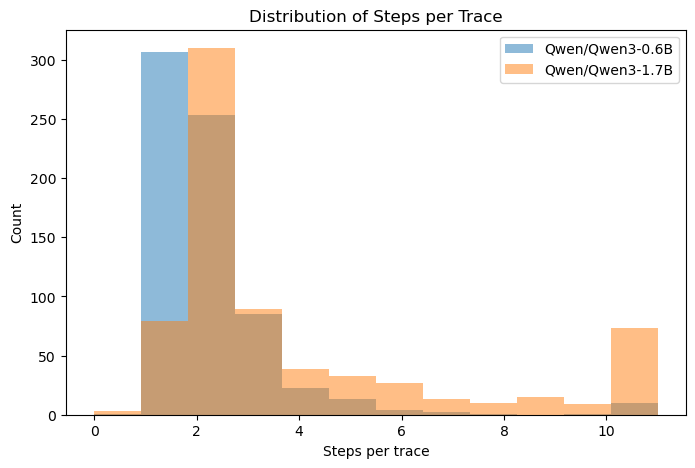

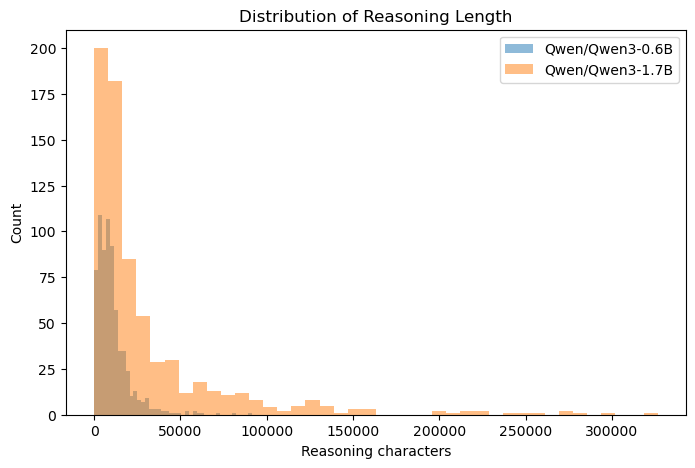

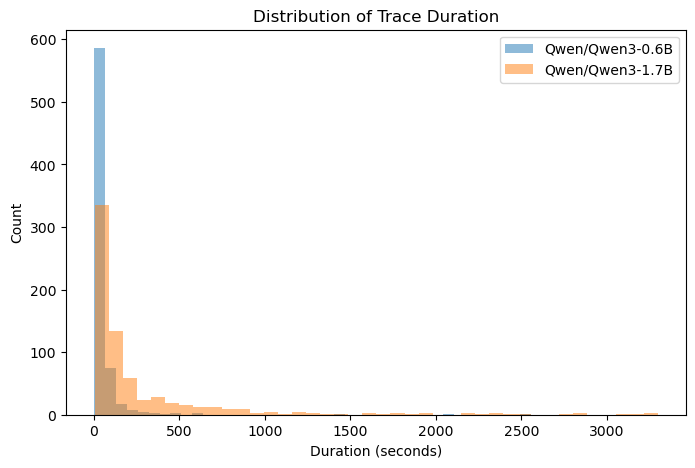

In [6]:
import matplotlib.pyplot as plt

models = df["model"].unique()

# Steps per trace
plt.figure(figsize=(8,5))
for model in models:
    subset = df[df["model"] == model]
    plt.hist(subset["steps"], bins=12, alpha=0.5, label=model)

plt.xlabel("Steps per trace")
plt.ylabel("Count")
plt.title("Distribution of Steps per Trace")
plt.legend()
plt.show()


# Reasoning chars per trace
plt.figure(figsize=(8,5))
for model in models:
    subset = df[df["model"] == model]
    plt.hist(subset["reasoning_chars"], bins=40, alpha=0.5, label=model)

plt.xlabel("Reasoning characters")
plt.ylabel("Count")
plt.title("Distribution of Reasoning Length")
plt.legend()
plt.show()


# Duration per trace
plt.figure(figsize=(8,5))
for model in models:
    subset = df[df["model"] == model]
    plt.hist(subset["duration_s"], bins=40, alpha=0.5, label=model)

plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Distribution of Trace Duration")
plt.legend()
plt.show()

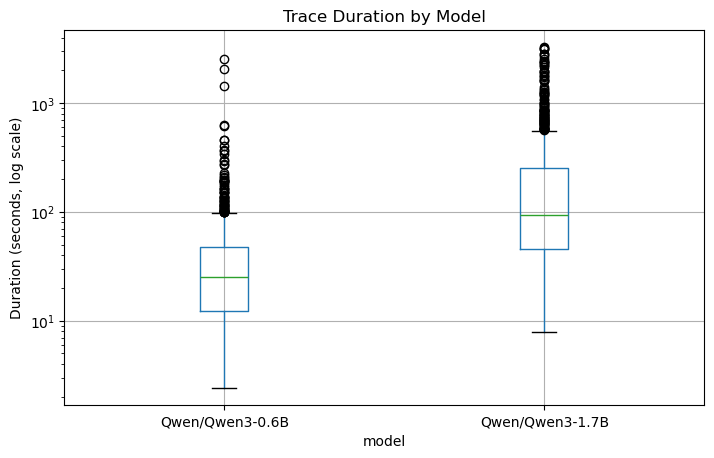

In [ ]:
import matplotlib.pyplot as plt

# heavy-tailed distributions

fig, ax = plt.subplots(figsize=(8,5))

df.boxplot(
    column="duration_s",
    by="model",
    ax=ax
)

ax.set_yscale("log")
ax.set_ylabel("Duration (seconds, log scale)")
ax.set_title("Trace Duration by Model")
plt.suptitle("")
plt.show()

In [8]:
none_count = 0

for trace in parsed_traces:
    for step in trace["llm_steps"]:
        if step.get("reasoning_content") is None:
            none_count += 1

print(f"Steps with reasoning_content=None: {none_count}")

Steps with reasoning_content=None: 10
